In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_s_curve

from Autoencoders import ConformalAutoencoder
from helper import load_optimizer_and_scheduler, save_optimizer_and_scheduler
from data import make_half_sphere

random_state = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
    
    def forward(self, x):
        return self.fc(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )
    
    def forward(self, z):
        return self.fc(z)

In [3]:
data, labels = make_half_sphere(n_samples=2000, noise=0.05, random_state=random_state)
data = torch.tensor(data, dtype=torch.float32).to(device)
val_data, val_labels = make_half_sphere(n_samples=1000, noise=0.05, random_state=random_state)
val_data = torch.tensor(val_data, dtype=torch.float32).to(device)

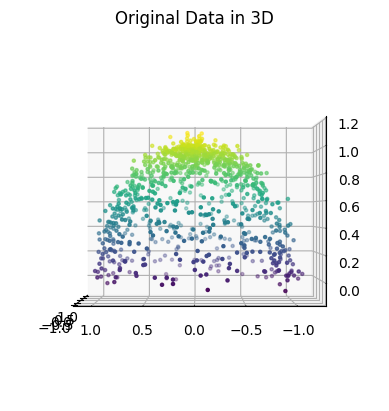

In [4]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0].cpu(), data[:, 1].cpu(), data[:, 2].cpu(), c=labels, s=5)
ax.set_title("Original Data in 3D")
ax.view_init(0, 180, 0)
plt.show()

In [5]:
# define model parameters
latent_dim = 2
input_dim = data.shape[1]
output_dim = data.shape[1]
batch_size = 64

train_dataloader = DataLoader(data, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

model_path = "models/conformal_autoencoder_half_sphere.pth"
optimizer_path = "models/conformal_autoencoder_half_sphere_optimizer.pth"

In [6]:
from metrics import conformality4_loss

In [8]:
encoder = Encoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
decoder = Decoder(latent_dim=latent_dim, output_dim=output_dim).to(device)
conformal_autoencoder = ConformalAutoencoder(encoder, decoder, lambda_conf=10.0).to(device)
conformal_autoencoder.conformality_loss = conformality4_loss
optmizer, scheduler = conformal_autoencoder.train_model(train_dataloader, val_dataloader, batch_size=batch_size, epochs=1000, learning_rate=0.001, log_every=100, val_every=100, scheduler_kwargs={"step_size": 100, "gamma": 0.5})

/home/maxheise/anaconda3/envs/ML/lib/python3.13/site-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch [100/1000], Loss: -2772743475123191808.00000000, Reconstruction Loss: 109.56765747, Conformal Loss: -277274344076345344.00000000
Epoch [100/1000], Validation Loss: -1043328164144611328.00000000, Reconstruction Loss: 53.30437469, Conformal Loss: -104332812978487296.00000000
Epoch [200/1000], Loss: -708235915222319104.00000000, Reconstruction Loss: 2.90072846, Conformal Loss: -70823589804244992.00000000
Epoch [200/1000], Validation Loss: -457475967632277504.00000000, Reconstruction Loss: 3.17126489, Conformal Loss: -45747599340208128.00000000
Epoch [300/1000], Loss: -582977282843344896.00000000, Reconstruction Loss: 1.78516853, Conformal Loss: -58297730002321408.00000000
Epoch [300/1000], Validation Loss: -768817150486904832.00000000, Reconstruction Loss: 2.48649597, Conformal Loss: -76881718484664320.00000000
Epoch [400/1000], Loss: -284884974585249792.00000000, Reconstruction Loss: 1.05742729, Conformal Loss: -28488500894498816.00000000
Epoch [400/1000], Validation Loss: -9840131

In [7]:
conformal_autoencoder.save_checkpoint(model_path)
save_optimizer_and_scheduler(optimizer_path, optmizer, scheduler)

Checkpoint saved to models/conformal_autoencoder_half_sphere.pth at epoch 1001
Optimizer and scheduler saved to models/conformal_autoencoder_half_sphere_optimizer.pth


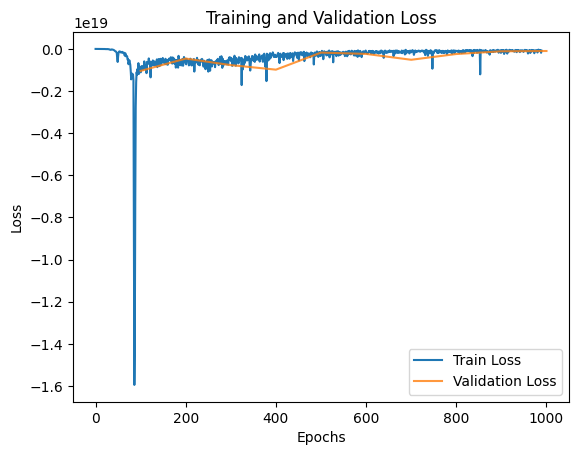

In [9]:
plt.plot(conformal_autoencoder.loss_list[10:], label='Train Loss')
plt.plot(np.linspace(100, 1000, 10), conformal_autoencoder.val_loss_list, alpha=0.8, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

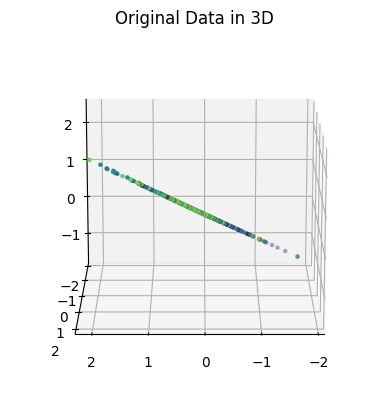

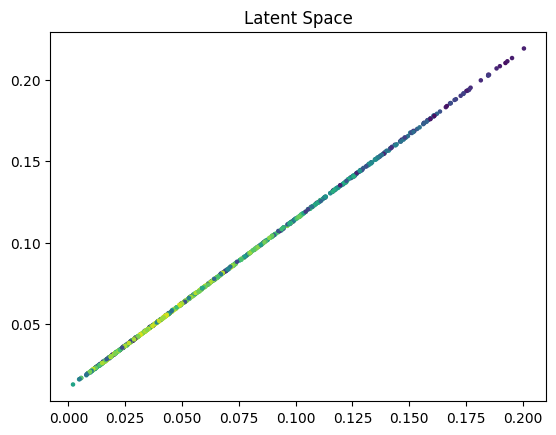

In [10]:
#Encode the data
encoded_data = conformal_autoencoder.encode(data)
# Decode the data
decoded_data = conformal_autoencoder.decode(encoded_data).cpu().detach()
encoded_data = encoded_data.cpu().detach()

# Visualize the reconstruction
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(decoded_data[:, 0], decoded_data[:, 1], decoded_data[:, 2], c=labels, cmap='viridis', s=5)
ax.set_title("Original Data in 3D")
ax.view_init(15, 90, 0)
plt.show()
# Visualize the latent space
plt.scatter(encoded_data[:, 0], encoded_data[:, 1], c=labels, cmap='viridis', s=5)
plt.title("Latent Space")
plt.show()

In [15]:
num = 900
J = torch.zeros((num, 2, 2))
for i in range(num):
    latent = encoder(data[i:i+1])
    jac = torch.autograd.functional.jacobian(decoder, latent)
    jac = jac[0,:,0,:]
    J[i] = jac.T @ jac
print(J.mean(dim=0))
print(J.std(dim=0))

tensor([[ 9.2623e-03, -2.3381e-05],
        [-2.3381e-05,  9.9772e-03]])
tensor([[0.0027, 0.0018],
        [0.0018, 0.0025]])


In [12]:
# Load the model and optimizer from checkpoint
encoder = Encoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
decoder = Decoder(latent_dim=latent_dim, output_dim=output_dim).to(device)
autoencoder = ConformalAutoencoder(encoder, decoder).load_model_from_checkpoint(model_path).to(device)
optimizer = autoencoder.get_default_optimizer()
scheduler = autoencoder.get_default_scheduler(optimizer)
optimizer, scheduler = load_optimizer_and_scheduler(optimizer_path, optimizer, scheduler)

Model and custom variables loaded from models/conformal_autoencoder_half_sphere.pth
Optimizer and scheduler loaded from models/conformal_autoencoder_half_sphere_optimizer.pth
